In [2]:
import pandas as pd

df = pd.read_csv("Titanic-Dataset.csv")

# Cleaning (same as before)
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df = df.drop_duplicates()
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S


## 📂 Data Preparation:

- Dataset loaded successfully
- Missing values handled
- Data cleaned and ready for modeling

In [4]:
X = df[['Pclass', 'Sex', 'Age', 'Fare']]
y = df['Survived']

## 🎯 Feature Selection:

- Selected features:
  - Pclass (Passenger class)
  - Sex (Gender)
  - Age
  - Fare
- Target variable:
  - Survived (0 = No, 1 = Yes)

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

## 🔀 Data Splitting:

- Dataset split into training and testing sets
- 80% training data
- 20% testing data
- Helps evaluate model performance on unseen data

In [6]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## 🤖 Model Training:

- Logistic Regression algorithm used
- Model trained using training dataset
- Ready to make predictions

In [7]:
y_pred = model.predict(X_test)

## 🔮 Predictions:

- Model used to predict survival on test data
- Predictions stored in y_pred

In [8]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7877094972067039


## 📊 Model Accuracy:

- Accuracy measures how many predictions are correct
- Higher accuracy = better model performance

In [9]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[91 23]
 [15 50]]


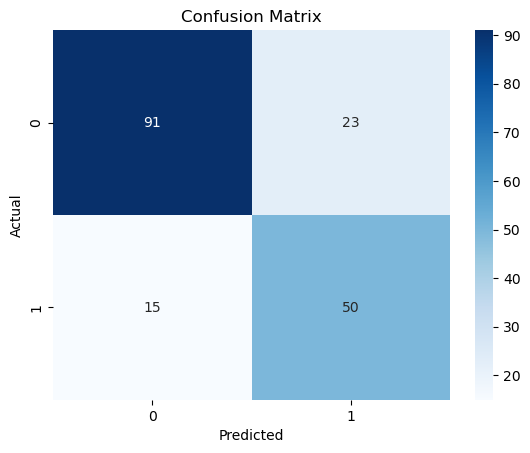

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 📦 Confusion Matrix:

- Shows correct and incorrect predictions
- True Positive, True Negative, False Positive, False Negative
- Helps understand model performance in detail

In [11]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.80      0.83       114
           1       0.68      0.77      0.72        65

    accuracy                           0.79       179
   macro avg       0.77      0.78      0.78       179
weighted avg       0.80      0.79      0.79       179



## 📑 Classification Report:

- Includes precision, recall, and F1-score
- Gives deeper insight into model performance